Saved: btc_ftest_analysis.png

=== Group Statistics ===
Weekdays      n= 243  mean=-0.0200%  std=2.6077%  var=6.8281×10⁻⁴
Weekends      n= 102  mean=-0.0154%  std=1.5498%  var=2.4257×10⁻⁴
Holidays      n=  19  mean=-0.1391%  std=1.1693%  var=1.4432×10⁻⁴

=== One-way ANOVA ===
F = 0.0247,  p = 0.975647

=== Levene's Test ===
W = 10.1114,  p = 0.000053

=== Bartlett's Test ===
B = 42.4694,  p = 0.000000

=== Pairwise F-ratios ===
Weekdays vs Weekends            F = 2.8149,  p = 0.000000  ✓ significant
Weekdays vs Holidays            F = 4.7312,  p = 0.000394  ✓ significant
Weekends vs Holidays            F = 1.6808,  p = 0.208386  ~ borderline


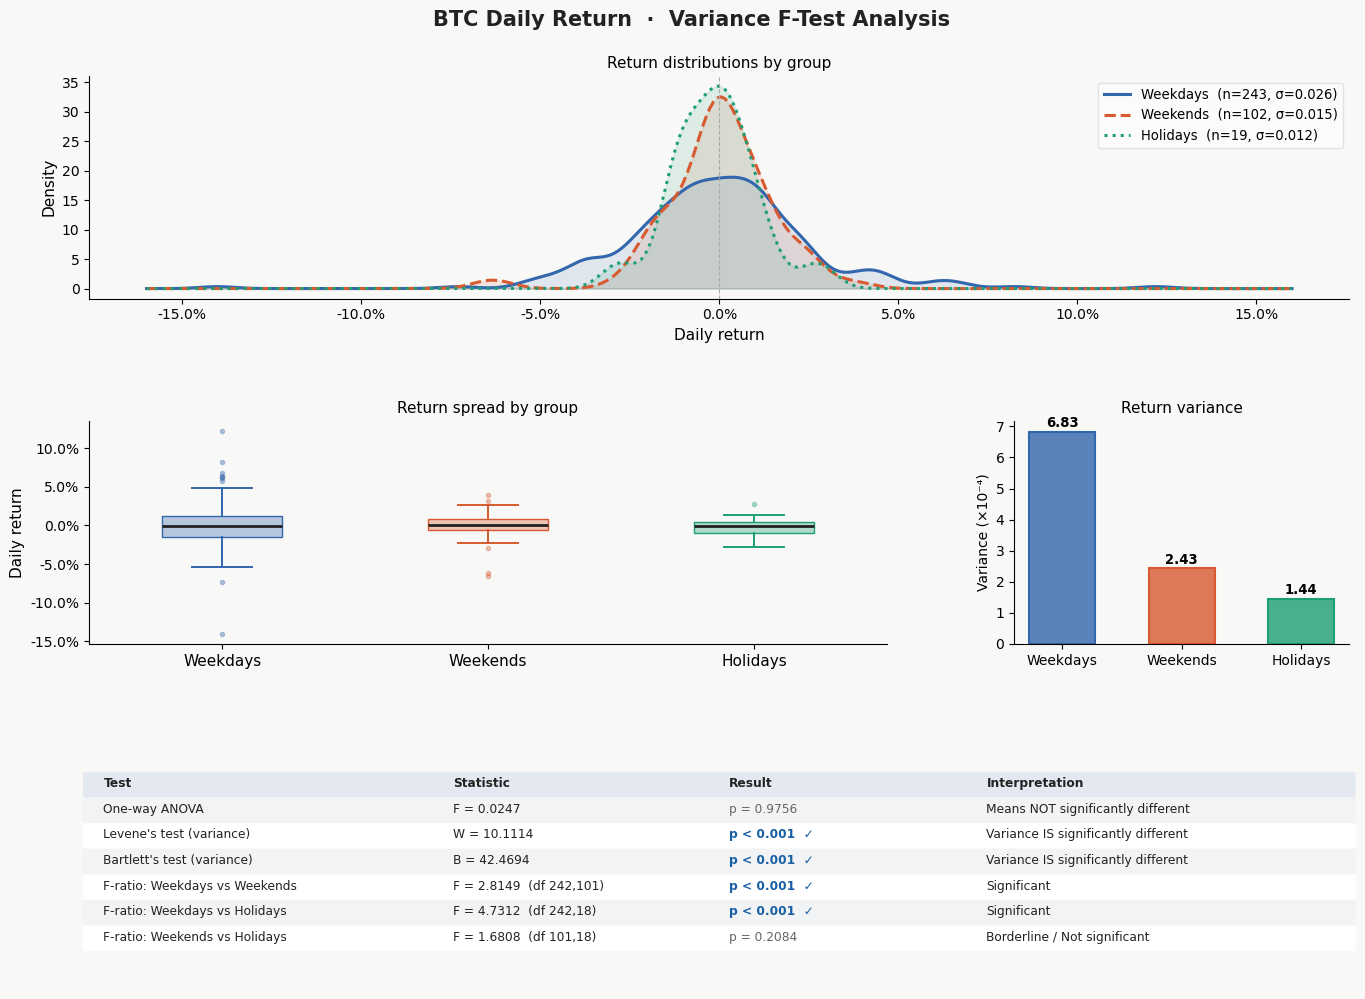

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("btc_fng_with_holidays_api.csv", parse_dates=["date"])
df["btc_return_pct"] = pd.to_numeric(df["btc_return_pct"], errors="coerce")
df = df.dropna(subset=["btc_return_pct"])
df = df[df["btc_return_pct"].between(-1, 1)]

# ── Build groups ───────────────────────────────────────────────────────────────
weekdays = df.loc[~df["is_weekend"] & ~df["is_holiday"], "btc_return_pct"].values
weekends = df.loc[ df["is_weekend"] & ~df["is_holiday"], "btc_return_pct"].values
holidays = df.loc[ df["is_holiday"], "btc_return_pct"].values

groups      = [weekdays, weekends, holidays]
labels      = ["Weekdays", "Weekends", "Holidays"]
colors      = ["#3266ad", "#d85a30", "#1d9e75"]
colors_light= ["#3266ad33", "#d85a3033", "#1d9e7533"]

# ── Statistical tests ──────────────────────────────────────────────────────────
f_anova,  p_anova  = stats.f_oneway(*groups)
lev_w,    lev_p    = stats.levene(*groups)
bart_b,   bart_p   = stats.bartlett(*groups)

pair_labels = ["Weekdays vs Weekends", "Weekdays vs Holidays", "Weekends vs Holidays"]
pair_groups = [(weekdays, weekends), (weekdays, holidays), (weekends, holidays)]
pair_results = []
for (a, b), lbl in zip(pair_groups, pair_labels):
    f_ratio = a.var(ddof=1) / b.var(ddof=1)
    df1, df2 = len(a) - 1, len(b) - 1
    p_val = 2 * min(stats.f.cdf(f_ratio, df1, df2),
                    stats.f.sf(f_ratio, df1, df2))
    pair_results.append({"label": lbl, "F": f_ratio, "p": p_val,
                          "df1": df1, "df2": df2})

# ── KDE helper ─────────────────────────────────────────────────────────────────
def kde(data, bw=0.005, n=300):
    xs = np.linspace(-0.16, 0.16, n)
    ys = np.array([
        np.sum(np.exp(-0.5 * ((xs[i] - data) / bw) ** 2))
        / (len(data) * bw * np.sqrt(2 * np.pi))
        for i in range(n)
    ])
    return xs, ys

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11), facecolor="#f8f8f6")
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.55, wspace=0.38,
                         left=0.07, right=0.97,
                         top=0.90, bottom=0.07)

ax_kde  = fig.add_subplot(gs[0, :])       # full-width KDE
ax_box  = fig.add_subplot(gs[1, :2])      # boxplot
ax_var  = fig.add_subplot(gs[1, 2])       # variance bars
ax_tbl  = fig.add_subplot(gs[2, :])       # results table

fig.suptitle("BTC Daily Return  ·  Variance F-Test Analysis",
             fontsize=15, fontweight="bold", color="#222", y=0.96)

# ── 1. KDE distributions ───────────────────────────────────────────────────────
ax_kde.set_facecolor("#f8f8f6")
linestyles = ["-", "--", ":"]
for g, lbl, col, ls in zip(groups, labels, colors, linestyles):
    xs, ys = kde(g)
    ax_kde.fill_between(xs, ys, alpha=0.12, color=col)
    ax_kde.plot(xs, ys, color=col, lw=2.2, ls=ls,
                label=f"{lbl}  (n={len(g)}, σ={g.std():.3f})")

ax_kde.axvline(0, color="#aaa", lw=0.8, ls="--")
ax_kde.set_xlabel("Daily return", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("Return distributions by group", fontsize=11, pad=6)
ax_kde.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
ax_kde.legend(fontsize=9.5, framealpha=0.5, loc="upper right")
ax_kde.spines[["top","right"]].set_visible(False)
ax_kde.set_facecolor("#f8f8f6")

# ── 2. Box plots ───────────────────────────────────────────────────────────────
ax_box.set_facecolor("#f8f8f6")
bp = ax_box.boxplot(groups, patch_artist=True, widths=0.45,
                    medianprops=dict(color="#222", lw=2),
                    whiskerprops=dict(lw=1.4),
                    capprops=dict(lw=1.4),
                    flierprops=dict(marker="o", markersize=3, alpha=0.35))
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col + "55")
    patch.set_edgecolor(col)
for whisker, col in zip(bp["whiskers"], [c for c in colors for _ in range(2)]):
    whisker.set_color(col)
for cap, col in zip(bp["caps"], [c for c in colors for _ in range(2)]):
    cap.set_color(col)
for flier, col in zip(bp["fliers"], colors):
    flier.set_markerfacecolor(col)
    flier.set_markeredgecolor(col)

ax_box.set_xticks([1, 2, 3])
ax_box.set_xticklabels(labels, fontsize=11)
ax_box.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax_box.set_ylabel("Daily return", fontsize=11)
ax_box.set_title("Return spread by group", fontsize=11, pad=6)
ax_box.spines[["top","right"]].set_visible(False)

# ── 3. Variance bars ───────────────────────────────────────────────────────────
ax_var.set_facecolor("#f8f8f6")
variances = [g.var(ddof=1) * 1e4 for g in groups]
bars = ax_var.bar(labels, variances, color=[c + "cc" for c in colors],
                  edgecolor=colors, linewidth=1.5, width=0.55)
for bar, val in zip(bars, variances):
    ax_var.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
ax_var.set_ylabel("Variance (×10⁻⁴)", fontsize=10)
ax_var.set_title("Return variance", fontsize=11, pad=6)
ax_var.spines[["top","right"]].set_visible(False)
ax_var.set_facecolor("#f8f8f6")

# ── 4. Results table ───────────────────────────────────────────────────────────
ax_tbl.axis("off")
ax_tbl.set_facecolor("#f8f8f6")

def sig_str(p):
    if p < 0.001: return "p < 0.001  ✓"
    if p < 0.01:  return f"p = {p:.4f}  ✓"
    if p < 0.05:  return f"p = {p:.4f}  ✓"
    return f"p = {p:.4f}"

def sig_col(p):
    return "#185fa5" if p < 0.05 else "#666"

rows = [
    ["Test", "Statistic", "Result", "Interpretation"],
    ["One-way ANOVA",
     f"F = {f_anova:.4f}",
     sig_str(p_anova),
     "Means NOT significantly different"],
    ["Levene's test (variance)",
     f"W = {lev_w:.4f}",
     sig_str(lev_p),
     "Variance IS significantly different"],
    ["Bartlett's test (variance)",
     f"B = {bart_b:.4f}",
     sig_str(bart_p),
     "Variance IS significantly different"],
]
for pr in pair_results:
    rows.append([
        f"F-ratio: {pr['label']}",
        f"F = {pr['F']:.4f}  (df {pr['df1']},{pr['df2']})",
        sig_str(pr['p']),
        "Significant" if pr['p'] < 0.05 else "Borderline / Not significant"
    ])

col_widths = [0.28, 0.22, 0.20, 0.30]
col_x      = [0.0, 0.28, 0.50, 0.70]
row_h      = 0.115
start_y    = 0.97

for r_idx, row in enumerate(rows):
    y = start_y - r_idx * row_h
    is_header = r_idx == 0

    # Row background
    bg_col = "#e4e8f0" if is_header else ("#ffffff" if r_idx % 2 == 0 else "#f2f3f5")
    rect = FancyBboxPatch((0, y - row_h + 0.01), 1.0, row_h - 0.01,
                           boxstyle="round,pad=0.005",
                           facecolor=bg_col, edgecolor="none",
                           transform=ax_tbl.transAxes, clip_on=False)
    ax_tbl.add_patch(rect)

    for c_idx, (cell, cx, cw) in enumerate(zip(row, col_x, col_widths)):
        fw = "bold" if is_header else "normal"
        # Color significant p-values in result column
        fc = "#222"
        if not is_header and c_idx == 2:
            p_val = [p_anova, lev_p, bart_p] + [pr["p"] for pr in pair_results]
            fc = sig_col(p_val[r_idx - 1])
            fw = "bold" if p_val[r_idx - 1] < 0.05 else "normal"

        ax_tbl.text(cx + cw * 0.04, y - row_h * 0.42, cell,
                    transform=ax_tbl.transAxes,
                    fontsize=8.8, fontweight=fw, color=fc, va="center",
                    ha="left", clip_on=False)

plt.savefig("btc_ftest_analysis.png", dpi=150, bbox_inches="tight",
            facecolor="#f8f8f6")
print("Saved: btc_ftest_analysis.png")

# ── Print summary ──────────────────────────────────────────────────────────────
print("\n=== Group Statistics ===")
for g, lbl in zip(groups, labels):
    print(f"{lbl:12s}  n={len(g):4d}  mean={g.mean()*100:+.4f}%  "
          f"std={g.std()*100:.4f}%  var={g.var(ddof=1)*1e4:.4f}×10⁻⁴")

print(f"\n=== One-way ANOVA ===\nF = {f_anova:.4f},  p = {p_anova:.6f}")
print(f"\n=== Levene's Test ===\nW = {lev_w:.4f},  p = {lev_p:.6f}")
print(f"\n=== Bartlett's Test ===\nB = {bart_b:.4f},  p = {bart_p:.6f}")
print("\n=== Pairwise F-ratios ===")
for pr in pair_results:
    flag = "✓ significant" if pr["p"] < 0.05 else "~ borderline"
    print(f"{pr['label']:30s}  F = {pr['F']:.4f},  p = {pr['p']:.6f}  {flag}")